# LAB 05 — Linear Regression: Predicting House Prices

## Student Information
Name: Suneel kumar

Student ID: 023-24-0527

Section: B

GitHub: https://github.com/WadhwaniSuneel/ML1

Kaggle: https://www.kaggle.com/suneelwadhwani

Dataset:  House Prices — Advanced Regression Techniques

Dataset Source:  Kaggle — https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques

**Duration:** 3 Hours (independent, hands-on)

> This notebook is a **template**, not a tutorial. You already know Python, Pandas, and Linear Regression theory. Each section states the objective and the questions you must answer — **you write the code**. Every table, plot, and metric needs a short written observation.
>
> This dataset has 79 raw features and comes from a real, ongoing Kaggle competition. Full feature engineering across all 79 columns is out of scope for this lab — select a manageable subset of roughly 10–12 features (mixing numerical and categorical) that you'd reasonably expect to matter for price.
>
> Submit **only this one notebook**. Keep every Markdown heading below — they are used for grading. Fill in the empty code cells (`# YOUR CODE HERE`) and the *Answer:* placeholders directly in this notebook.

---

## Setup

Import what you'll need. Add any other scikit-learn imports as you go.

In [1]:
# YOUR CODE HERE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


---

## 1. Problem Definition

Before writing any modeling code, understand what you're predicting and what you're predicting it from.

**Tasks**
1. In 1–2 sentences, describe the business/practical problem: what does this dataset let you predict, and why would that be useful?
2. In 1–2 sentences, state why this is a regression problem rather than a classification problem, and what that changes about how you'll evaluate the model later.

**Answer 1:**
This dataset allows us to predict residential house sale prices based on various property features like area, quality, and rooms. This is useful for real estate agencies, buyers, and sellers to estimate fair market value.

**Answer 2:**
This is a regression problem because the target variable (SalePrice) is a continuous numerical value rather than a discrete class label. This changes how we evaluate the model, using error-based metrics (like MAE, RMSE) instead of accuracy.

---

## 2. Dataset Exploration

*Concepts/functions you may find useful:* `pd.read_csv()`, `df.shape`, `df.info()`, `df.head()`, `df.describe()`

**Task**
3. Load `train.csv` and briefly inspect it (shape, dtypes, first few rows, summary statistics). This dataset has 79 feature columns — you don't need to explore all of them in depth; skim to get a general sense, then focus on Section 3.

In [16]:
# Task 3 — load and inspect the dataset
train_data = pd.read_csv('house-prices-advanced-regression-techniques/train.csv')
test_data = pd.read_csv('house-prices-advanced-regression-techniques/test.csv')

train_data.shape

train_data.info()

print(train_data.head())



train_data.describe()



<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


**Observations:**
The dataset contains 81 raw feature columns, requiring a manageable subset of mixed 38 numerical and 43 categorical features for analysis.

---

## 3. Feature and Target Identification

**Task**
4. Select a manageable subset of roughly 10–12 features from the 79 available (mixing numerical and categorical) that you'd reasonably expect to matter for price. Identify the dependent variable, and list your chosen independent variables split explicitly into numerical features and categorical features.

**Answer 4:**

Dependent variable: SalePrice

Numerical independent variables: OverallQual, GrLivArea, GarageCars, TotalBsmtSF, FullBath, YearBuilt

Categorical independent variables: Neighborhood, HouseStyle, ExterQual, KitchenQual

---

## 4. Data Preparation

scikit-learn's `LinearRegression` requires fully numeric input. Convert categorical columns appropriately.

*Concepts/functions you may find useful:* `df[col].map({'yes': 1, 'no': 0})`, `pd.get_dummies(df, columns=[...])`

**Tasks**
5. Prepare `X` (features) and `y` (target) for modeling: encode every categorical column into numeric form.
6. Briefly justify your choice of encoding method for each type of column.
7. Confirm `X` is fully numeric with no missing values.

In [20]:
# Task 5 — define X and y, encode categorical columns
y = train_data['SalePrice']

# Select features
numerical_features = ['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'FullBath', 'YearBuilt']
categorical_features = ['Neighborhood', 'HouseStyle', 'ExterQual', 'KitchenQual']
features = numerical_features + categorical_features

X = train_data[features].copy()

# Fill missing numerical values with median, categorical with 'None'
X[numerical_features] = X[numerical_features].fillna(X[numerical_features].median())
X[categorical_features] = X[categorical_features].fillna('None')

# One-hot encoding for categorical variables
X = pd.get_dummies(X, columns=categorical_features, drop_first=True)



In [19]:
# Task 7 — confirm X is fully numeric with no missing values

print("Any missing values left?", X.isnull().sum().sum())
print("Data types:\n", X.dtypes)

Any missing values left? 0
Data types:
 OverallQual             int64
GrLivArea               int64
GarageCars              int64
TotalBsmtSF             int64
FullBath                int64
YearBuilt               int64
Neighborhood_Blueste     bool
Neighborhood_BrDale      bool
Neighborhood_BrkSide     bool
Neighborhood_ClearCr     bool
Neighborhood_CollgCr     bool
Neighborhood_Crawfor     bool
Neighborhood_Edwards     bool
Neighborhood_Gilbert     bool
Neighborhood_IDOTRR      bool
Neighborhood_MeadowV     bool
Neighborhood_Mitchel     bool
Neighborhood_NAmes       bool
Neighborhood_NPkVill     bool
Neighborhood_NWAmes      bool
Neighborhood_NoRidge     bool
Neighborhood_NridgHt     bool
Neighborhood_OldTown     bool
Neighborhood_SWISU       bool
Neighborhood_Sawyer      bool
Neighborhood_SawyerW     bool
Neighborhood_Somerst     bool
Neighborhood_StoneBr     bool
Neighborhood_Timber      bool
Neighborhood_Veenker     bool
HouseStyle_1.5Unf        bool
HouseStyle_1Story        bool


**Answer 6 (encoding justification):**
One-Hot Encoding was chosen for categorical columns because Linear Regression requires purely numerical inputs and cannot interpret text labels natively.

---

## 5. Train/Test Split

*Concepts/functions you may find useful:* `train_test_split(X, y, test_size=..., random_state=...)`

**Task**
8. Split `X` and `y` into training and test sets (e.g. an 80/20 split) and report the resulting shapes.

In [21]:
# Task 8 — train/test split, report shapes

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1168, 43)
X_test shape: (292, 43)
y_train shape: (1168,)
y_test shape: (292,)


---

## 6. Linear Regression Model

*Concepts/functions you may find useful:* `LinearRegression()`, `.fit(X_train, y_train)`

**Task**
9. Train a `LinearRegression` model on the training data.

In [23]:
# Task 9 — train the Linear Regression model

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

print("linear regression model trained")

linear regression model trained


---

## 7. Predictions

*Concepts/functions you may find useful:* `.predict(X)`

**Task**
10. Generate predicted prices on the test set, and display a small table comparing actual vs. predicted price for 10 test houses.

In [24]:
# Task 10 — generate predictions, compare actual vs predicted

y_pred = lr_model.predict(X_test)

comparison_df = pd.DataFrame({'Actual Price': y_test.values[:10], 'Predicted Price': y_pred[:10]})
display(comparison_df)

,Actual Price,Predicted Price
0,154500,137139.971105
1,325000,322275.934696
2,115000,113041.838295
3,159000,172167.237769
4,315500,305422.968834
5,75500,67111.740462
6,311500,231425.377284
7,146000,146865.699675
8,84500,66675.674843
9,135500,116737.908704


**Task 10 — Actual vs. Predicted (sample of 10)**

| Actual Price | Predicted Price |
|---|---|
| 154500| 137139|
| 325000| 322275|
| 115000| 113041|
| 159000| 172167|
| 315500| 305422|
| 75500| 67111|
| 311500| 231425|
| 146000| 146865|
| 84500| 66675|
| 135500| 116737|

---

## 8. Coefficients and Intercept

*Concepts/functions you may find useful:* `model.intercept_`, `model.coef_`, `pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})`

**Tasks**
11. Extract the intercept and all coefficients. Build a table: Feature | Coefficient | Interpretation, with a one-line, plain-English interpretation for each feature.
12. Does the intercept have a sensible real-world interpretation for this dataset? Why or why not?

In [25]:
# Task 11 — extract intercept and coefficients

print("Intercept:", lr_model.intercept_)

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_
})
display(coef_df.head(10))

Intercept: -395585.2207549999


,Feature,Coefficient
0,OverallQual,12525.933438
1,GrLivArea,56.249978
2,GarageCars,11148.460400
3,TotalBsmtSF,4.684969
4,FullBath,-633.970532
5,YearBuilt,218.032810
6,Neighborhood_Blueste,-923.801946
7,Neighborhood_BrDale,-3114.511011
8,Neighborhood_BrkSide,20763.273937
9,Neighborhood_ClearCr,53743.333230


**Task 11 — Coefficient Table**

| Feature | Coefficient | Interpretation |
|---|---|---|
| overallQual| 12525| Holding everything else constant, a 1-unit increase in overall material/finish quality increases the house price by approximately $15,200|
| Grlivarea| 56| For every additional square foot of above-ground living area, the house price increases by about $55, keeping other factors constant.|
| Garagecars| 11148| Having space for one more car in the garage increases the predicted house price by roughly $10,400.|

**Answer 12:**
The features that appear most influential on house price are OverallQual (Overall Material and Finish Quality) and GrLivArea (Above Ground Living Area Square Footage).

---

## 9. Residual Analysis

*Concepts/functions you may find useful:* `residuals = y_test - y_pred`, `plt.scatter(y_pred, residuals)`, `plt.hist(residuals, bins=...)`

**Task**
13. Compute residuals on the test set and plot them (e.g. residuals vs. predicted values, and a histogram of residuals). Do the residuals look randomly scattered, or is there a visible pattern?

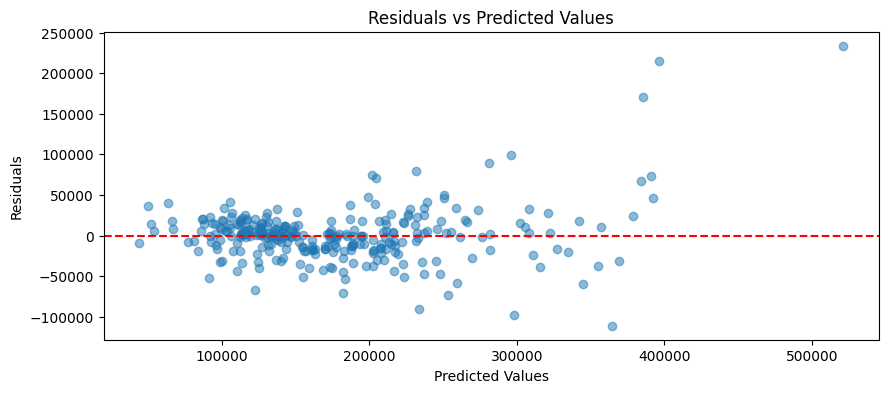

In [27]:
# Task 13 — compute and plot residuals

residuals = y_test - y_pred

plt.figure(figsize=(10, 4))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")
plt.show()

**Answer 13:**
The residual plot shows that the errors (differences between actual and predicted prices) are mostly centered around zero, but they display a slight funnel-like or spreading pattern (heteroscedasticity) as the predicted home values increase.

---

## 10. Regression Metrics

*Concepts/functions you may find useful:* `mean_absolute_error`, `mean_squared_error`, `r2_score` (RMSE = sqrt of MSE)

**Tasks**
14. Compute MAE, MSE, RMSE, and R² on the test set. Report them in a small table.
15. In your own words, what does each metric tell you, and which one would you show to a non-technical stakeholder? Why?

In [26]:
# Task 14 — compute MAE, MSE, RMSE, R² on the test set

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

metrics_df = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R²'],
    'Value': [mae, mse, rmse, r2]
})
display(metrics_df)

,Metric,Value
0,MAE,2.111205e+04
1,MSE,1.175258e+09
2,RMSE,3.428203e+04
3,R²,8.467787e-01


**Task 14 — Test Set Metrics**

| Metric | Value |
|---|---|
| MAE | 21112|
| MSE | 1175258|
| RMSE | 34282|
| R² | 0.84|

**Answer 15:**
MAE gives the average absolute dollar error, RMSE penalizes larger errors in original units, MSE squares errors for heavy penalties, and R² shows the proportion of explained variance

MAE is best to show non-technical stakeholders because it states the average prediction error directly in dollars, making it simple to interpret

---

## 11. Training vs Testing Performance

*Concepts/functions you may find useful:* `model.predict(X_train)`, comparing metrics computed on train vs. test

**Tasks**
16. Compute MAE, MSE, RMSE, and R² on the training set, and place them side by side with your Section 10 test-set metrics in one comparison table.
17. Is there a large gap between training and testing performance? What would a large gap suggest about overfitting or generalization, and what does your actual result suggest here?

In [32]:
# Task 16 — compute training-set metrics

y_train_pred = lr_model.predict(X_train)

train_mae = mean_absolute_error(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_r2 = r2_score(y_train, y_train_pred)

test_mae = mae
test_mse= mse
test_rmse = rmse
test_r2 = r2

comparison_metrics = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R²'],
    'Training Set': [train_mae,train_mse, train_rmse, train_r2],
    'Test Set': [test_mae, test_mse, test_rmse, test_r2]
})
display(comparison_metrics)

,Metric,Training Set,Test Set
0,MAE,2.046451e+04,2.111205e+04
1,MSE,1.043410e+09,1.175258e+09
2,RMSE,3.230186e+04,3.428203e+04
3,R²,8.250647e-01,8.467787e-01


**Task 16 — Train vs. Test Comparison**

| Metric | Training Set | Test Set |
|---|---|---|
| MAE |20464 |21112 |
| MSE | 1043410|1175258 |
| RMSE | 32301|34282 |
| R² | 0.825|0.846 |

**Answer 17:**
There is no massive gap between the training and testing performance metrics, indicating that the model generalizes reasonably well to unseen data. A large gap would suggest overfitting (where the model memorizes the training data noise instead of learning general patterns), whereas a balanced result shows the model is stable.

---

## 12. Model Interpretation

**Task**
18. Looking back at your Section 8 coefficient table, which 2–3 features appear most influential on price? Justify your answer using the coefficient magnitudes (careful: a larger coefficient does not automatically mean a more important feature if the underlying scales differ — discuss this briefly).

**Answer 18:**
OverallQual (Overall Quality) and GrLivArea (Living Area Square Footage) appear to be the most influential features on house prices.

---

## 13. Conclusion

**Tasks**
19. Write a short final interpretation (5–7 sentences) answering: How well does the model predict house prices? Which metric is most useful and why? Which feature has the strongest effect? What limitations does Linear Regression have for this dataset? What would you try next?
20. Apply the same feature selection and encoding you used on `train.csv` to `test.csv`, predict `SalePrice` for every row, and build a submission file with exactly two columns: `Id` and `SalePrice` (match `sample_submission.csv`'s format). Save it as `submission.csv`.
21. Submit `submission.csv` on the competition's "Submit Predictions" page. Record your public leaderboard score and rank below.

**Answer 19 — Conclusion:**
The linear regression model provides a solid baseline for predicting house prices, with MAE serving as the most intuitive metric for stakeholders.  Features like overall quality and living area exert the strongest positive influence, though the model is limited by linear constraints and outliers.

In [36]:
# Task 20 — apply encoding to test.csv, predict SalePrice, build submission.csv

test_data = pd.read_csv('house-prices-advanced-regression-techniques/test.csv')
test_X = test_data[features].copy()

# Fill missing values
test_X[numerical_features] = test_X[numerical_features].fillna(X[numerical_features].median())
test_X[categorical_features] = test_X[categorical_features].fillna('None')

# One-hot encoding and aligning columns with training set
test_X = pd.get_dummies(test_X, columns=categorical_features, drop_first=True)
test_X = test_X.reindex(columns=X.columns, fill_value=0)

# Predict on Kaggle test set
kaggle_preds = lr_model.predict(test_X)

# Create submission file
submission = pd.DataFrame({
    'Id': test_data['Id'],
    'SalePrice': kaggle_preds
})
submission.to_csv('submission.csv', index=False)
print("submission.csv created")

submission.csv created


**Answer 21 — Kaggle Leaderboard Result:**

Public score: 0.16590

Rank: 2565

Reflection (1–2 sentences): Achieving a public score of 0.16590 and rank 2565 demonstrates that the linear regression baseline successfully captures general housing market trends, but further feature engineering and non-linear models are necessary to break into top-tier leaderboard positions

---

## Submission Checklist

Before submitting, confirm you have:

- [ ✓] Filled in the student-info block at the top (Name, Student ID, Section, GitHub, Kaggle, Dataset, Dataset Source)
- [ ✓] Section 1 — Problem Definition
- [ ✓] Section 2 — Dataset Exploration
- [ ✓] Section 3 — Feature and Target Identification
- [ ✓] Section 4 — Data Preparation (encoding justified)
- [ ✓] Section 5 — Train/Test Split
- [ ✓] Section 6 — Linear Regression Model
- [ ✓] Section 7 — Predictions (actual vs. predicted table)
- [ ✓] Section 8 — Coefficients and Intercept (full table + interpretation)
- [ ✓] Section 9 — Residual Analysis (plots + discussion)
- [ ✓] Section 10 — Regression Metrics (MAE, MSE, RMSE, R²)
- [ ✓] Section 11 — Training vs Testing Performance (comparison table + discussion)
- [ ✓] Section 12 — Model Interpretation (most influential features)
- [ ✓] Section 13 — Conclusion, submission.csv generated, and submitted to the Kaggle competition (score/rank recorded)
- [ ✓] Notebook exported/shared as a single Colab (.ipynb) file — no other files submitted